In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt
from utils import Student, accept_reject

# Test on synthetic HMM with Student emissions


In [15]:
mu_th    = [0.05,  -0.01]
sigma_th = [0.008,  0.015]
nu_th = [20, 3]

A_th = np.array([[0.9, 0.1],
                  [0.05, 0.95]])



def generate_student_data(A_th, mu_th, sigma_th, nu_th,T=2000, seed=42):
    
    fmax_s= []
    
    for s in range(len(mu_th)):
        fmax_s.append(Student(mu_th[s], mu_th[s], sigma_th[s], nu_th[s]))
    
    rng = np.random.default_rng(seed)
    
    states, obs = [], []
    s = 0
    for _ in range(T):
        states.append(s)
        # Student's t sample
        x = accept_reject(Student, [mu_th[s], sigma_th[s], nu_th[s]], fmax=fmax_s[0], xmin=mu_th[s]-10*sigma_th[s], xmax=mu_th[s]+10*sigma_th[s])
        obs.append(x)
        s = rng.choice(2, p=A_th[s])

    return np.array(obs), np.array(states)

In [16]:
obs, states = generate_student_data(A_th, mu_th, sigma_th, nu_th,T=20000, seed=42)
obs=obs.reshape((1, obs.shape[0]))

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,   1.,   2.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   1.,
          0.,   1.,   1.,   1.,   2.,   1.,   3.,   2.,   2.,   2.,   0.,
          0.,   1.,   2.,   5.,   0.,   2.,   1.,   1.,   3.,   0.,   3.,
          3.,   3.,   3.,   4.,   3.,   5.,   2.,   1.,   4.,   3.,   5.,
          1.,   5.,   1.,   4.,   2.,   5.,   4.,   1.,   2.,   5.,   5.,
          8.,   7.,   5.,   8.,   6.,   9.,   7.,  10.,   7.,  10.,  16.,
          4.,  11.,  17.,  14.,   5.,  21.,  18.,  25.,  13.,  18.,  24.,
         23.,  27.,  28.,  35.,  37.,  36.,  29.,  32.,  45.,  61.,  54.,
         58.,  61.,  64.,  83.,  85.,  93., 124.,  91., 125., 114., 139.,
        178., 162., 185., 237., 212., 245., 251., 273., 273., 307., 313.,
        320., 345., 366., 351., 372., 348., 381., 356., 382., 340., 319.,
        322., 334., 270., 306., 274., 265., 230., 222., 208., 193., 169.,
        166., 130., 141., 142., 108., 

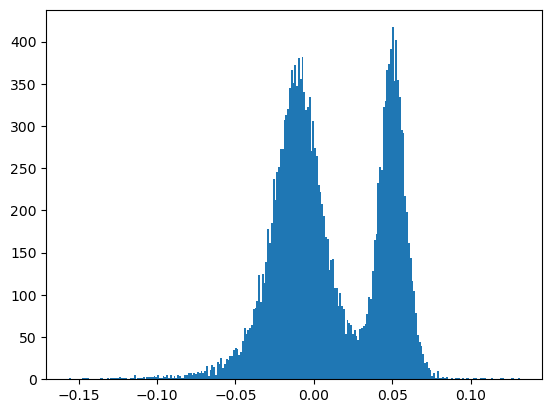

In [17]:
plt.hist(obs[0, :], bins=250)

In [5]:
from tqdm import tqdm
### Student emissions
err_t = []
final_err = []
HMM_list = []
N_cycles = 10

for i in range(N_cycles):
    
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), np.random.uniform(3, 20)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), np.random.uniform(3, 20)],  # state 1
    ])
    
    emission = emission_model.Student_Emission(2, obs, params)
    HMM = hmm.Hmm(2, emission, pi, A=None, eps=1e-8)
    
    err_t.append(HMM.Baum_Welch(obs, N_max=35))
    final_err.append(err_t[i][-1])
    HMM_list.append(HMM)
    

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  -logL =      -1.270581  |  -ΔL/L = 100.000000%
Iteration    2  |  -logL =      -1.971037  |  -ΔL/L = 55.128770%
Iteration    3  |  -logL =      -2.006881  |  -ΔL/L = 1.818530%
Iteration    4  |  -logL =      -2.033192  |  -ΔL/L = 1.311009%
Iteration    5  |  -logL =      -2.066218  |  -ΔL/L = 1.624341%
Iteration    6  |  -logL =      -2.115438  |  -ΔL/L = 2.382159%
Iteration    7  |  -logL =      -2.204125  |  -ΔL/L = 4.192358%
Iteration    8  |  -logL =      -2.339387  |  -ΔL/L = 6.136753%
Iteration    9  |  -logL =      -2.481939  |  -ΔL/L = 6.093555%
Iteration   10  |  -logL =      -2.520837  |  -ΔL/L = 1.567278%
Iteration   11  |  -logL =      -2.522369  |  -ΔL/L = 0.060745%
Iteration   12  |  -logL =      -2.522660  |  -ΔL/L = 0

In [13]:
# choose the HMM with the lowest -logL
HMM = HMM_list[np.argmin(np.array(final_err))]

HMM.emission.params = HMM.emission.params[np.argsort(HMM.emission.params[:, 0]), :]

th_sort = np.argsort(np.array(mu_th))
mu_th = np.array(mu_th)[th_sort]
sigma_th = np.array(sigma_th)[th_sort]
nu_th = np.array(nu_th)[th_sort]

print(r'Synthetic Student generating processes$ (\mu, \sigma, \nu)$: ')
print(' ')
print([(float(mu_th[i]), float(sigma_th[i]), float(nu_th[i])) for i in range(len(mu_th))])
print(' ')
print(r'Learned Student generating processes: HMM.emission.params')
print(' ')
print([(float(np.round(HMM.emission.params[i, 0], 4)), (float(np.round(HMM.emission.params[i, 1], 4))), (float(np.round(HMM.emission.params[i, 2], 4)))) for i in range(HMM.emission.params.shape[0])])



Synthetic Student generating processes$ (\mu, \sigma, \nu)$: 
 
[(-0.01, 0.015, 3.0), (0.05, 0.008, 20.0)]
 
Learned Student generating processes: HMM.emission.params
 
[(-0.0102, 0.015, 3.0047), (0.0498, 0.0081, 23.5688)]


In [7]:
np.argsort(np.array(mu_th))

array([0, 1])